# Kid Attendance Prediction — Outdoor English Events

**Domain:** an English e-learning platform for kids. Outdoor events (storytelling in the park, treasure hunts, sports days, nature walks).

**Business goal:** increase event attendance / reduce no-show rates.

**ML goal:** binary classifier — given a registration, predict whether the kid will attend.

- Target: `attended` (1 = ATTENDED, 0 = NO_SHOW)
- Class balance: ~50/50 (balanced at generation time)
- Models compared: **RandomForest**, **XGBoost**, and **Artificial Neural Network (ANN / MLP)**
- Primary metric: **ROC-AUC**; secondary: **PR-AUC**, **F1 on no-show**

## 1. Setup

In [1]:
# %pip install pandas numpy scikit-learn xgboost matplotlib seaborn joblib

In [2]:
import warnings
warnings.filterwarnings('ignore')

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import joblib

from sklearn.model_selection import train_test_split, StratifiedKFold, cross_val_score
from sklearn.preprocessing import OneHotEncoder, StandardScaler
from sklearn.compose import ColumnTransformer
from sklearn.pipeline import Pipeline
from sklearn.ensemble import RandomForestClassifier
from sklearn.neural_network import MLPClassifier
from sklearn.metrics import (
    classification_report, confusion_matrix, roc_auc_score, average_precision_score,
    roc_curve, precision_recall_curve, f1_score, accuracy_score
)
from xgboost import XGBClassifier

RANDOM_STATE = 42
sns.set_theme(style='whitegrid')

## 2. Load raw data

In [3]:
df_raw = pd.read_csv('dataset.csv')
print('Raw shape :', df_raw.shape)
df_raw.head()

Raw shape : (10200, 16)


,kid_age,kid_english_level,previous_events_attended,previous_no_shows,event_category,event_target_level,event_duration_hours,event_price_tnd,distance_km,days_until_event,is_weekend,event_is_featured,weather_rain_prob,weather_temp_c,sms_reminder_sent,attended
0,8,A2_ELEMENTARY,11,3,Treasure_hunt,B1_INTERMEDIATE,1.5,29,?,0,1,0,0.338,27.8,0,1
1,10,A1_BEGINNER,29,10,OUTDOOR_THEATER,B1_INTERMEDIATE,3.0,58,0.86,15,no,0,0.261,14.7,1,0
2,11,A2_ELEMENTARY,9,4,ENGLISH_CAMP_DAY,A1_BEGINNER,2.0,53,7.73,11,0,0,0.478,NaN,0,0
3,13,B1_INTERMEDIATE,12,0,NATURE_VOCAB_WALK,B1_INTERMEDIATE,4.0,0,17.09,18,1,1,0.405,28.5,0,1
4,12,B1_INTERMEDIATE,12,1,OUTDOOR_THEATER,A2_ELEMENTARY,1.0,17,2.38,17,1,0,0.512,21.3,1,1


In [4]:
df_raw.info()

<class 'pandas.DataFrame'>
RangeIndex: 10200 entries, 0 to 10199
Data columns (total 16 columns):
 #   Column                    Non-Null Count  Dtype  
---  ------                    --------------  -----  
 0   kid_age                   10001 non-null  str    
 1   kid_english_level         9997 non-null   str    
 2   previous_events_attended  10200 non-null  int64  
 3   previous_no_shows         10200 non-null  int64  
 4   event_category            9986 non-null   str    
 5   event_target_level        10006 non-null  str    
 6   event_duration_hours      10200 non-null  float64
 7   event_price_tnd           10200 non-null  int64  
 8   distance_km               9993 non-null   str    
 9   days_until_event          10200 non-null  int64  
 10  is_weekend                10200 non-null  str    
 11  event_is_featured         10200 non-null  int64  
 12  weather_rain_prob         10003 non-null  str    
 13  weather_temp_c            9999 non-null   str    
 14  sms_reminder_sent

## 3. Data cleaning

Five issues to handle:
1. **Duplicate rows**
2. **Multiple missing-value markers** — `""`, `"N/A"`, `"null"`, `"?"`, `"NA"`, `"unknown"`
3. **Inconsistent text** in `event_category` (lower-case, capitalized, padded with whitespace)
4. **Wrong types** — `sms_reminder_sent` and `is_weekend` sometimes stored as `"yes"`/`"no"`
5. **Outliers** — `kid_age=99`, `distance_km=99999`, `event_price_tnd=999999`

Each step prints a before/after count.

In [5]:
df = df_raw.copy()
n0 = len(df)

# 3.1 Duplicates
dup = df.duplicated().sum()
df = df.drop_duplicates().reset_index(drop=True)
print(f'[duplicates]  removed {dup} rows  ->  {len(df)} remaining')

[duplicates]  removed 94 rows  ->  10106 remaining


In [6]:
# 3.2 Missing-value markers -> NaN
MISSING_MARKERS = ['', 'N/A', 'null', '?', 'NA', 'unknown']
df = df.replace(MISSING_MARKERS, np.nan)
print(df.isna().sum()[df.isna().sum() > 0].sort_values(ascending=False))

weather_temp_c        319
event_category        306
kid_english_level     306
distance_km           306
kid_age               304
weather_rain_prob     297
event_target_level    283
dtype: int64


In [7]:
# 3.3 Normalize event_category text
VALID_CATEGORIES = [
    'STORYTELLING_PARK','NATURE_VOCAB_WALK','TREASURE_HUNT','ROLE_PLAY_GAMES',
    'ENGLISH_PICNIC','SPORTS_AND_ENGLISH','OUTDOOR_THEATER','ARTS_AND_CRAFTS',
    'FIELD_TRIP','ENGLISH_CAMP_DAY',
]
before = df['event_category'].dropna().unique()
df['event_category'] = df['event_category'].astype(str).str.strip().str.upper()
df.loc[~df['event_category'].isin(VALID_CATEGORIES), 'event_category'] = np.nan
after = df['event_category'].dropna().unique()
print(f'[event_category] unique values: before={len(before)}  ->  after={len(after)}')

[event_category] unique values: before=40  ->  after=10


In [8]:
# 3.4 Coerce wrong types
yes_no_map = {'yes': 1, 'no': 0, 'Yes': 1, 'No': 0, 'YES': 1, 'NO': 0}
for c in ['sms_reminder_sent', 'is_weekend', 'event_is_featured']:
    df[c] = df[c].replace(yes_no_map)
    df[c] = pd.to_numeric(df[c], errors='coerce')

NUMERIC_COLS = [
    'kid_age','previous_events_attended','previous_no_shows',
    'event_duration_hours','event_price_tnd','distance_km','days_until_event',
    'is_weekend','event_is_featured','weather_rain_prob','weather_temp_c',
    'sms_reminder_sent','attended',
]
for c in NUMERIC_COLS:
    df[c] = pd.to_numeric(df[c], errors='coerce')
print('Numeric dtypes ok:', (df[NUMERIC_COLS].dtypes != 'object').all())

Numeric dtypes ok: True


In [9]:
# 3.5 Outliers -> NaN
RANGES = {
    'kid_age':         (4, 16),
    'distance_km':     (0, 100),
    'event_price_tnd': (0, 500),
    'weather_temp_c':  (-10, 50),
    'weather_rain_prob': (0, 1),
}
for col, (lo, hi) in RANGES.items():
    bad = ((df[col] < lo) | (df[col] > hi)).sum()
    df.loc[(df[col] < lo) | (df[col] > hi), col] = np.nan
    print(f'[outliers] {col:18s}: {bad} out-of-range -> NaN')

[outliers] kid_age           : 60 out-of-range -> NaN
[outliers] distance_km       : 51 out-of-range -> NaN
[outliers] event_price_tnd   : 24 out-of-range -> NaN
[outliers] weather_temp_c    : 0 out-of-range -> NaN
[outliers] weather_rain_prob : 0 out-of-range -> NaN


In [10]:
# 3.6 Imputation
num_cols = df.select_dtypes(include=[np.number]).columns
cat_cols = df.select_dtypes(exclude=[np.number]).columns
df[num_cols] = df[num_cols].fillna(df[num_cols].median(numeric_only=True))
df[cat_cols] = df[cat_cols].fillna('UNKNOWN')
df = df[df['attended'].isin([0, 1])].reset_index(drop=True)
df['attended'] = df['attended'].astype(int)
print(f'[done] cleaned shape: {df.shape}  (started at {n0})')
print(f'Remaining missing values: {int(df.isna().sum().sum())}')

[done] cleaned shape: (10106, 16)  (started at 10200)
Remaining missing values: 0


In [11]:
# 3.7 Feature engineering
# (a) past attendance rate (handles 0/0 division safely)
df['past_attendance_rate'] = np.where(
    df['previous_events_attended'] > 0,
    (df['previous_events_attended'] - df['previous_no_shows']) / df['previous_events_attended'].clip(lower=1),
    0.5,
)
# (b) level match
df['level_match'] = (
    (df['event_target_level'] == 'ALL_LEVELS') |
    (df['kid_english_level'] == df['event_target_level'])
).astype(int)
df[['past_attendance_rate', 'level_match']].describe()

,past_attendance_rate,level_match
count,10106.000000,10106.000000
mean,0.690028,0.474669
std,0.192967,0.499383
min,0.000000,0.000000
25%,0.500000,0.000000
50%,0.672619,0.000000
75%,0.850000,1.000000
max,1.000000,1.000000


## 4. EDA

### 4.1 Class balance check — is the target balanced?

First thing to verify: are `attended` and `no_show` roughly equal? If not, accuracy becomes misleading and we'd need `class_weight='balanced'` or resampling. This dataset was balanced at generation time via rejection sampling, so we expect ~50/50.

Counts:
attended
no_show     5058
attended    5048
Name: count, dtype: int64

Percentages:
attended
no_show     50.05 %
attended    49.95 %
Name: proportion, dtype: str

Majority/minority ratio: 1.00  ->  BALANCED


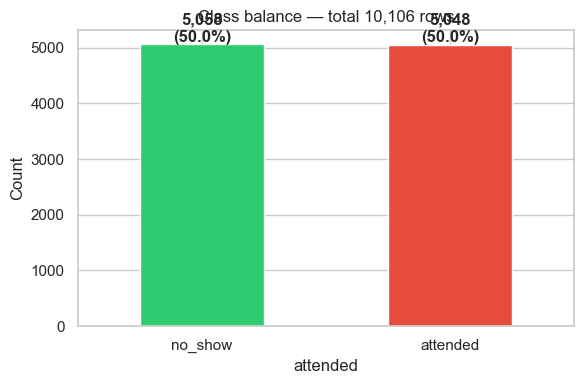

In [12]:
balance_counts = df['attended'].value_counts().rename({1: 'attended', 0: 'no_show'})
balance_pct = df['attended'].value_counts(normalize=True).rename({1: 'attended', 0: 'no_show'})
print('Counts:')
print(balance_counts)
print('\nPercentages:')
print((balance_pct * 100).round(2).astype(str) + ' %')

ratio = balance_counts.max() / balance_counts.min()
verdict = 'BALANCED' if ratio < 1.5 else ('MILDLY IMBALANCED' if ratio < 3 else 'IMBALANCED')
print(f'\nMajority/minority ratio: {ratio:.2f}  ->  {verdict}')

fig, ax = plt.subplots(figsize=(6, 4))
balance_counts.plot(kind='bar', ax=ax, color=['#2ecc71', '#e74c3c'], rot=0)
ax.set_title(f'Class balance — total {len(df):,} rows')
ax.set_ylabel('Count')
for i, v in enumerate(balance_counts.values):
    ax.text(i, v + len(df) * 0.005, f'{v:,}\n({balance_pct.iloc[i]:.1%})',
            ha='center', fontweight='bold')
plt.tight_layout(); plt.show()

### 4.2 Feature relationships with the target

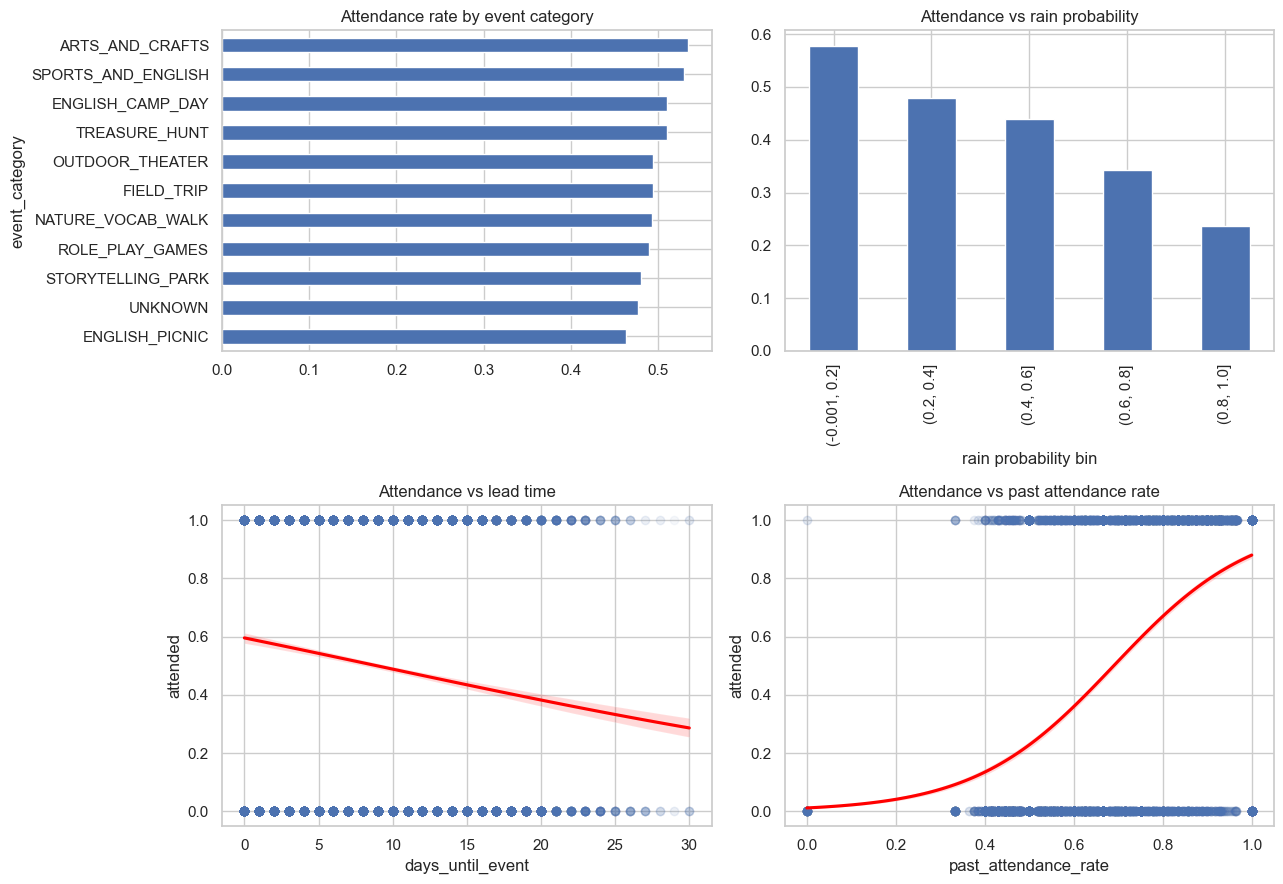

In [13]:
fig, axes = plt.subplots(2, 2, figsize=(13, 9))
df.groupby('event_category')['attended'].mean().sort_values().plot(
    kind='barh', ax=axes[0,0], title='Attendance rate by event category')
df.groupby(pd.cut(df['weather_rain_prob'], 5))['attended'].mean().plot(
    kind='bar', ax=axes[0,1], title='Attendance vs rain probability')
axes[0,1].set_xlabel('rain probability bin')
sns.regplot(x='days_until_event', y='attended', data=df, ax=axes[1,0],
            logistic=True, scatter_kws={'alpha': 0.05}, line_kws={'color': 'red'})
axes[1,0].set_title('Attendance vs lead time')
sns.regplot(x='past_attendance_rate', y='attended', data=df, ax=axes[1,1],
            logistic=True, scatter_kws={'alpha': 0.05}, line_kws={'color': 'red'})
axes[1,1].set_title('Attendance vs past attendance rate')
plt.tight_layout(); plt.show()

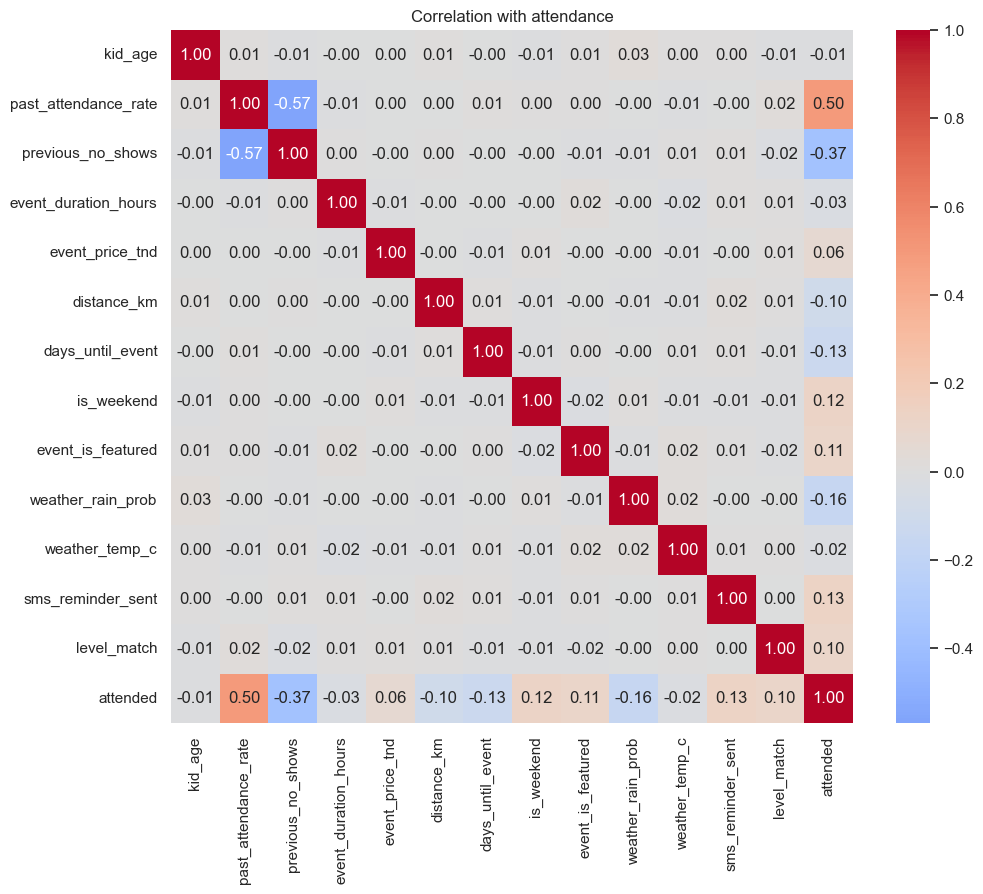

In [14]:
corr_cols = ['kid_age','past_attendance_rate','previous_no_shows','event_duration_hours',
             'event_price_tnd','distance_km','days_until_event','is_weekend',
             'event_is_featured','weather_rain_prob','weather_temp_c',
             'sms_reminder_sent','level_match','attended']
plt.figure(figsize=(11, 9))
sns.heatmap(df[corr_cols].corr(), annot=True, fmt='.2f', cmap='coolwarm', center=0)
plt.title('Correlation with attendance'); plt.show()

## 5. Preprocessing

In [15]:
TARGET = 'attended'
CAT_COLS = ['kid_english_level', 'event_category', 'event_target_level']
FEATURE_COLS = [c for c in df.columns if c != TARGET]
NUM_COLS = [c for c in FEATURE_COLS if c not in CAT_COLS]

X = df[FEATURE_COLS]
y = df[TARGET]
print('numeric features :', len(NUM_COLS))
print('cat     features :', len(CAT_COLS))
print('total            :', len(FEATURE_COLS))

numeric features : 14
cat     features : 3
total            : 17


In [16]:
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, stratify=y, random_state=RANDOM_STATE
)
print('train:', X_train.shape, ' test:', X_test.shape)

train: (8084, 17)  test: (2022, 17)


In [17]:
preprocess = ColumnTransformer([
    ('cat', OneHotEncoder(handle_unknown='ignore', sparse_output=False), CAT_COLS),
    ('num', 'passthrough', NUM_COLS),
])

## 6. Model 1 — RandomForest (baseline)

In [18]:
rf_pipe = Pipeline([
    ('prep', preprocess),
    ('clf', RandomForestClassifier(
        n_estimators=400,
        criterion='gini',
        max_depth=None,
        min_samples_split=2,
        min_samples_leaf=2,
        min_weight_fraction_leaf=0.0,
        max_features='sqrt',
        max_leaf_nodes=None,
        min_impurity_decrease=0.0,
        bootstrap=True,
        oob_score=False,
        n_jobs=-1,
        random_state=RANDOM_STATE,
        verbose=0,
        warm_start=False,
        class_weight=None,
        ccp_alpha=0.0,
        max_samples=None,
    )),
])
rf_pipe.fit(X_train, y_train)
rf_proba = rf_pipe.predict_proba(X_test)[:, 1]
rf_pred  = (rf_proba >= 0.5).astype(int)
print(f'Accuracy : {accuracy_score(y_test, rf_pred):.4f}')
print(f'ROC-AUC  : {roc_auc_score(y_test, rf_proba):.4f}')
print(f'PR-AUC   : {average_precision_score(y_test, rf_proba):.4f}')
print(classification_report(y_test, rf_pred, target_names=['no_show', 'attended']))

Accuracy : 0.7626
ROC-AUC  : 0.8368
PR-AUC   : 0.8279
              precision    recall  f1-score   support

     no_show       0.75      0.78      0.77      1012
    attended       0.77      0.74      0.76      1010

    accuracy                           0.76      2022
   macro avg       0.76      0.76      0.76      2022
weighted avg       0.76      0.76      0.76      2022



## 7. Model 2 — XGBoost (baseline)

In [19]:
xgb_pipe = Pipeline([
    ('prep', preprocess),
    ('clf', XGBClassifier(
        n_estimators=600,
        max_depth=6,
        learning_rate=0.05,
        booster='gbtree',
        tree_method='hist',
        gamma=0.0,
        min_child_weight=1,
        max_delta_step=0,
        subsample=0.9,
        sampling_method='uniform',
        colsample_bytree=0.9,
        colsample_bylevel=1.0,
        colsample_bynode=1.0,
        reg_alpha=0.0,
        reg_lambda=1.0,
        scale_pos_weight=1.0,
        objective='binary:logistic',
        eval_metric='auc',
        random_state=RANDOM_STATE,
        n_jobs=-1,
        verbosity=0,
    )),
])
xgb_pipe.fit(X_train, y_train)
xgb_proba = xgb_pipe.predict_proba(X_test)[:, 1]
xgb_pred  = (xgb_proba >= 0.5).astype(int)
print(f'Accuracy : {accuracy_score(y_test, xgb_pred):.4f}')
print(f'ROC-AUC  : {roc_auc_score(y_test, xgb_proba):.4f}')
print(f'PR-AUC   : {average_precision_score(y_test, xgb_proba):.4f}')
print(classification_report(y_test, xgb_pred, target_names=['no_show', 'attended']))

Accuracy : 0.7577
ROC-AUC  : 0.8350
PR-AUC   : 0.8307
              precision    recall  f1-score   support

     no_show       0.76      0.75      0.76      1012
    attended       0.76      0.76      0.76      1010

    accuracy                           0.76      2022
   macro avg       0.76      0.76      0.76      2022
weighted avg       0.76      0.76      0.76      2022



## 8. Model 3 — Artificial Neural Network (ANN / MLP)

A **Multi-Layer Perceptron** built with scikit-learn's `MLPClassifier`. This is a true ANN (input → hidden layers → output), trained by:

- **Forward propagation** — features pass through 3 hidden layers (64 → 32 → 16 neurons) with **ReLU** activation
- **Loss function** — `log_loss` (cross-entropy) for binary classification
- **Backpropagation** with the **Adam optimizer** (adaptive learning rate, combines momentum + RMSprop)
- **Regularization** — `alpha` (L2 weight penalty) + **early stopping** on validation loss

Note: ANNs need **scaled input** (unlike tree models), so we add a `StandardScaler` step. Categorical features remain one-hot encoded.

In [20]:
preprocess_ann = ColumnTransformer([
    ('cat', OneHotEncoder(handle_unknown='ignore', sparse_output=False), CAT_COLS),
    ('num', StandardScaler(), NUM_COLS),
])

ann_pipe = Pipeline([
    ('prep', preprocess_ann),
    ('clf', MLPClassifier(
        hidden_layer_sizes=(64, 32, 16),
        activation='relu',
        solver='adam',
        alpha=0.0001,
        batch_size=64,
        learning_rate='adaptive',
        learning_rate_init=0.001,
        power_t=0.5,
        max_iter=200,
        shuffle=True,
        random_state=RANDOM_STATE,
        tol=1e-4,
        verbose=False,
        warm_start=False,
        momentum=0.9,
        nesterovs_momentum=True,
        early_stopping=True,
        validation_fraction=0.1,
        beta_1=0.9,
        beta_2=0.999,
        epsilon=1e-8,
        n_iter_no_change=10,
    )),
])

ann_pipe.fit(X_train, y_train)
ann_proba = ann_pipe.predict_proba(X_test)[:, 1]
ann_pred  = (ann_proba >= 0.5).astype(int)
print(f'Accuracy : {accuracy_score(y_test, ann_pred):.4f}')
print(f'ROC-AUC  : {roc_auc_score(y_test, ann_proba):.4f}')
print(f'PR-AUC   : {average_precision_score(y_test, ann_proba):.4f}')
print(classification_report(y_test, ann_pred, target_names=['no_show', 'attended']))
mlp = ann_pipe.named_steps['clf']
print(f'Training stopped at epoch: {mlp.n_iter_}')

Accuracy : 0.7591
ROC-AUC  : 0.8458
PR-AUC   : 0.8418
              precision    recall  f1-score   support

     no_show       0.75      0.77      0.76      1012
    attended       0.77      0.75      0.76      1010

    accuracy                           0.76      2022
   macro avg       0.76      0.76      0.76      2022
weighted avg       0.76      0.76      0.76      2022

Training stopped at epoch: 14


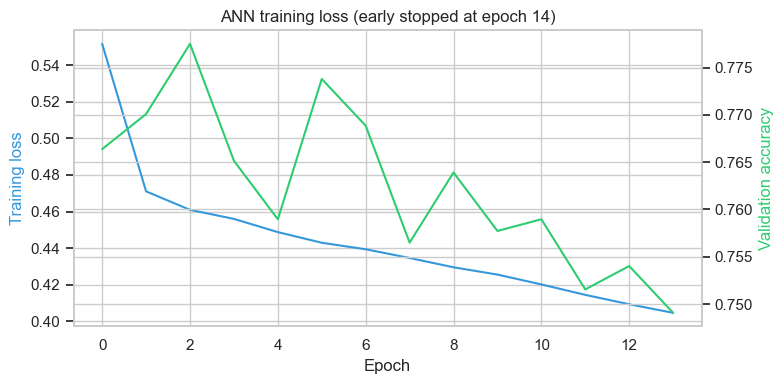

In [21]:
mlp = ann_pipe.named_steps['clf']
fig, ax = plt.subplots(figsize=(8, 4))
ax.plot(mlp.loss_curve_, label='training loss', color='#3498db')
if hasattr(mlp, 'validation_scores_') and mlp.validation_scores_:
    ax2 = ax.twinx()
    ax2.plot(mlp.validation_scores_, label='validation accuracy', color='#2ecc71')
    ax2.set_ylabel('Validation accuracy', color='#2ecc71')
ax.set_xlabel('Epoch'); ax.set_ylabel('Training loss', color='#3498db')
ax.set_title(f'ANN training loss (early stopped at epoch {mlp.n_iter_})')
plt.tight_layout(); plt.show()

## 9. Compare the three models

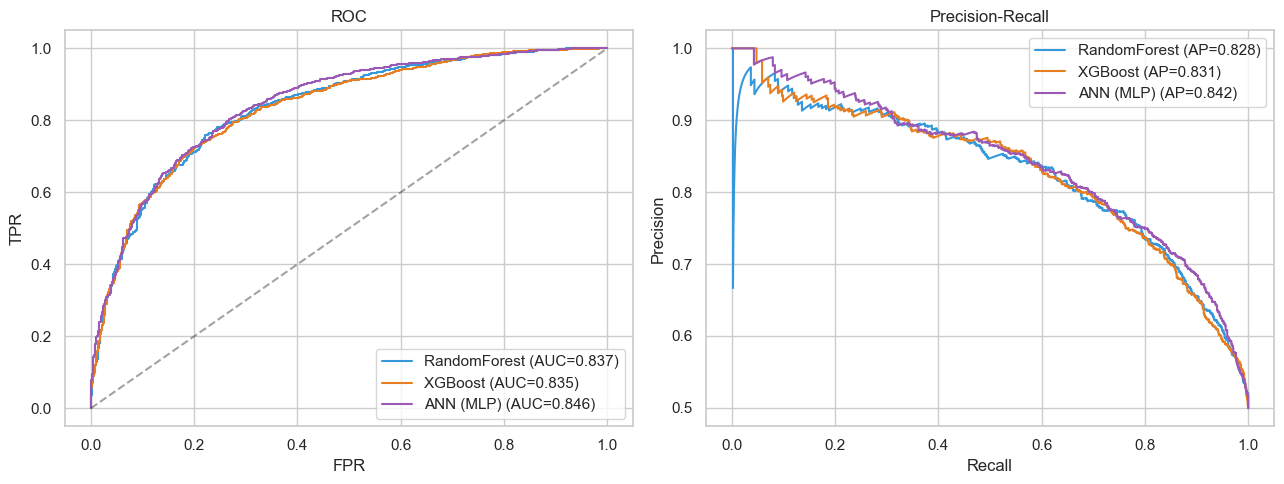

In [22]:
fig, axes = plt.subplots(1, 2, figsize=(13, 5))
models = [
    ('RandomForest', rf_proba, '#3498db'),
    ('XGBoost',      xgb_proba, '#e67e22'),
    ('ANN (MLP)',    ann_proba, '#9b59b6'),
]
for name, proba, color in models:
    fpr, tpr, _ = roc_curve(y_test, proba)
    axes[0].plot(fpr, tpr, label=f'{name} (AUC={roc_auc_score(y_test, proba):.3f})', color=color)
    pr, rc, _ = precision_recall_curve(y_test, proba)
    axes[1].plot(rc, pr, label=f'{name} (AP={average_precision_score(y_test, proba):.3f})', color=color)
axes[0].plot([0, 1], [0, 1], 'k--', alpha=0.4)
axes[0].set_xlabel('FPR'); axes[0].set_ylabel('TPR'); axes[0].set_title('ROC'); axes[0].legend()
axes[1].set_xlabel('Recall'); axes[1].set_ylabel('Precision'); axes[1].set_title('Precision-Recall'); axes[1].legend()
plt.tight_layout(); plt.show()

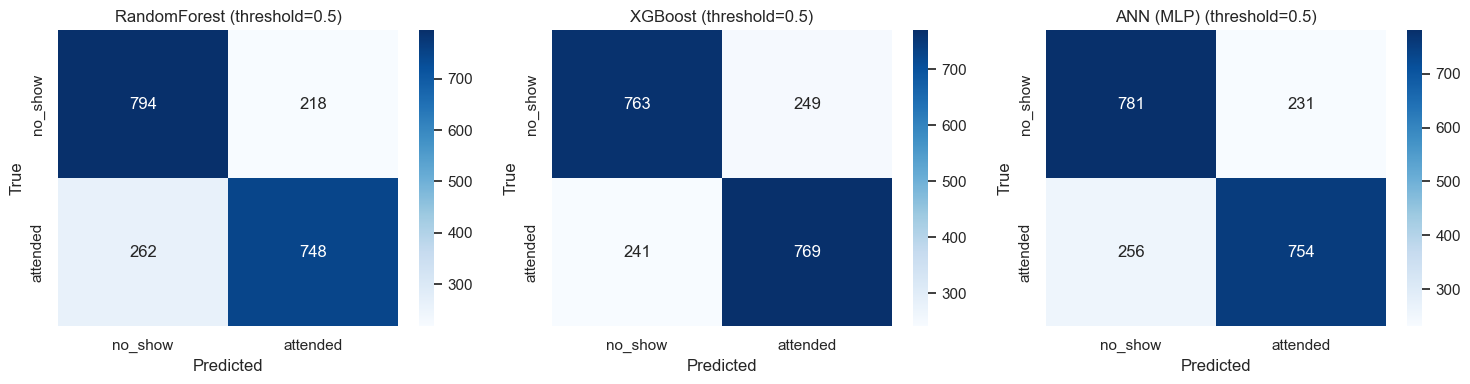

In [23]:
fig, axes = plt.subplots(1, 3, figsize=(15, 4))
for ax, (name, pred) in zip(axes, [('RandomForest', rf_pred), ('XGBoost', xgb_pred), ('ANN (MLP)', ann_pred)]):
    cm = confusion_matrix(y_test, pred)
    sns.heatmap(cm, annot=True, fmt='d', cmap='Blues', ax=ax,
                xticklabels=['no_show','attended'], yticklabels=['no_show','attended'])
    ax.set_title(f'{name} (threshold=0.5)'); ax.set_xlabel('Predicted'); ax.set_ylabel('True')
plt.tight_layout(); plt.show()

## 10. Feature importance (tree models only)

ANNs don't expose `feature_importances_` directly — their decision logic is distributed across thousands of weights. This is one trade-off of using neural networks: they're powerful but less interpretable. (You'd use SHAP or permutation importance to interpret an ANN.)

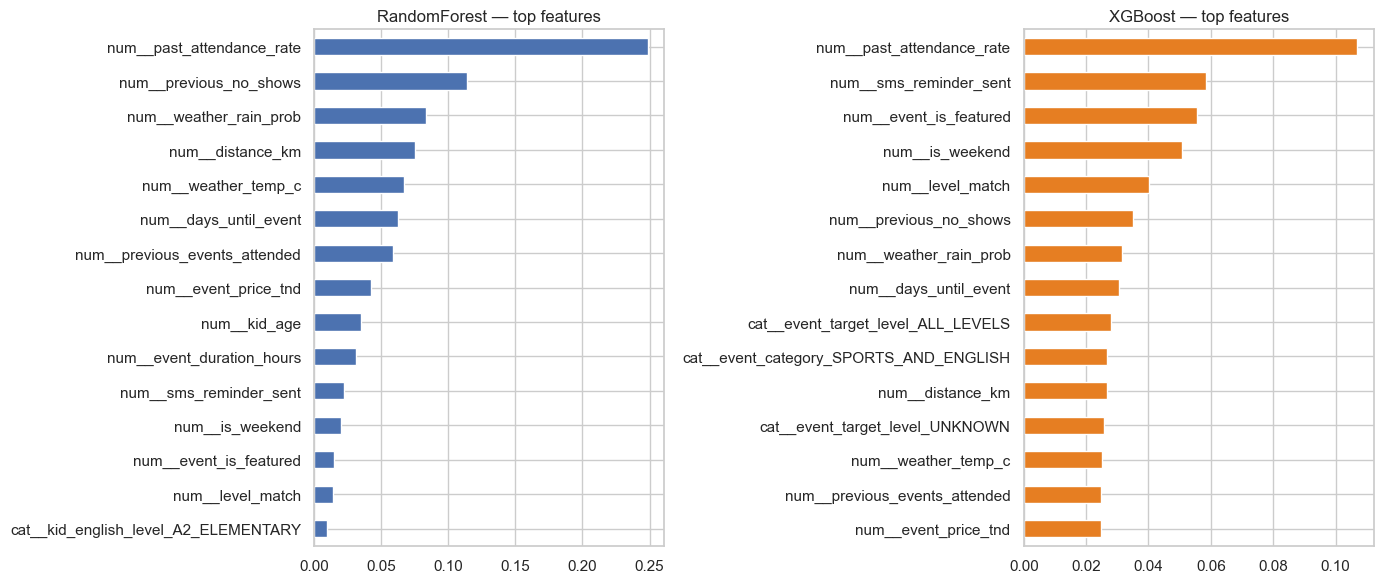

In [24]:
def importances_df(pipe, top_n=15):
    feature_names = pipe.named_steps['prep'].get_feature_names_out()
    imp = pipe.named_steps['clf'].feature_importances_
    return pd.Series(imp, index=feature_names).sort_values(ascending=False).head(top_n)

fig, axes = plt.subplots(1, 2, figsize=(14, 6))
importances_df(rf_pipe).iloc[::-1].plot(kind='barh', ax=axes[0], title='RandomForest — top features')
importances_df(xgb_pipe).iloc[::-1].plot(kind='barh', ax=axes[1], title='XGBoost — top features', color='#e67e22')
plt.tight_layout(); plt.show()

## 11. Cross-validated AUC (sanity check on overfitting)

In [25]:
cv = StratifiedKFold(n_splits=5, shuffle=True, random_state=RANDOM_STATE)
rf_auc  = cross_val_score(rf_pipe,  X, y, cv=cv, scoring='roc_auc', n_jobs=-1)
xgb_auc = cross_val_score(xgb_pipe, X, y, cv=cv, scoring='roc_auc', n_jobs=-1)
ann_auc = cross_val_score(ann_pipe, X, y, cv=cv, scoring='roc_auc', n_jobs=-1)
print(f'RandomForest 5-fold ROC-AUC : {rf_auc.mean():.4f} ± {rf_auc.std():.4f}')
print(f'XGBoost      5-fold ROC-AUC : {xgb_auc.mean():.4f} ± {xgb_auc.std():.4f}')
print(f'ANN (MLP)    5-fold ROC-AUC : {ann_auc.mean():.4f} ± {ann_auc.std():.4f}')

RandomForest 5-fold ROC-AUC : 0.8482 ± 0.0040
XGBoost      5-fold ROC-AUC : 0.8416 ± 0.0041
ANN (MLP)    5-fold ROC-AUC : 0.8516 ± 0.0052


## 12. Save artifacts (for the Flask app)

We save the **best-performing model** of the three as `model.joblib`. The Flask app loads this file at startup.

In [26]:
scores = {'rf': rf_auc.mean(), 'xgb': xgb_auc.mean(), 'ann': ann_auc.mean()}
pipes  = {'rf': rf_pipe,        'xgb': xgb_pipe,       'ann': ann_pipe}
best_name = max(scores, key=scores.get)
print(f'Best model: {best_name}  (CV AUC = {scores[best_name]:.4f})')
joblib.dump(pipes[best_name], 'model.joblib')
joblib.dump(rf_pipe,  'rf_pipeline.joblib')
joblib.dump(xgb_pipe, 'xgb_pipeline.joblib')
joblib.dump(ann_pipe, 'ann_pipeline.joblib')
print('Saved: model.joblib (used by Flask app), rf_pipeline.joblib, xgb_pipeline.joblib, ann_pipeline.joblib')

Best model: ann  (CV AUC = 0.8516)
Saved: model.joblib (used by Flask app), rf_pipeline.joblib, xgb_pipeline.joblib, ann_pipeline.joblib


## 13. Inference example — same input shape the Flask app sends

In [27]:
model = joblib.load('model.joblib')

sample = pd.DataFrame([{
    'kid_age': 8,
    'kid_english_level': 'A2_ELEMENTARY',
    'previous_events_attended': 5,
    'previous_no_shows': 1,
    'event_category': 'TREASURE_HUNT',
    'event_target_level': 'A2_ELEMENTARY',
    'event_duration_hours': 2,
    'event_price_tnd': 30,
    'distance_km': 5,
    'days_until_event': 4,
    'is_weekend': 1,
    'event_is_featured': 1,
    'weather_rain_prob': 0.1,
    'weather_temp_c': 24,
    'sms_reminder_sent': 1,
    'past_attendance_rate': (5 - 1) / 5,
    'level_match': 1,
}])
p_attend = model.predict_proba(sample)[0, 1]
print(f'P(attend)  = {p_attend:.3f}')
print(f'P(no_show) = {1 - p_attend:.3f}')
print(f'Prediction : {"WILL ATTEND" if p_attend >= 0.5 else "LIKELY NO-SHOW"}')

P(attend)  = 0.982
P(no_show) = 0.018
Prediction : WILL ATTEND
